In [10]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, anderson


#Grab data and put numerical vals in one table
#################################################################################################################
dataset_as_given = pd.read_csv(r"d:\Desktop\Practice Python\21.gym_members_exercise_tracking.csv")
#print(dataset_as_given)

# Get column names
column_names = dataset_as_given.columns
#print(column_names)

desired = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM", 
           "Session_Duration (hours)", "Calories_Burned", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]

dataset_as_given_numeric = dataset_as_given[desired]



#Get Rid of Outliers
#################################################################################################################

# Copy the dataset so you keep the original intact
cleaned_df = dataset_as_given.copy()

# Select numeric columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]



print("Original rows:", dataset_as_given.shape[0])
print("Cleaned rows:", cleaned_df.shape[0])
print("Rows removed:", dataset_as_given.shape[0] - cleaned_df.shape[0])


#################################################################################################################

encoded_df = cleaned_df.copy()

encoded_df['Gender'] = encoded_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

workout_dummies = pd.get_dummies(encoded_df['Workout_Type'], prefix='Workout', drop_first=True)
encoded_df = pd.concat([encoded_df.drop(columns=['Workout_Type']), workout_dummies], axis=1)




Original rows: 973
Cleaned rows: 931
Rows removed: 42


In [2]:
# ============================================================
#   TRAIN/TEST SPLIT + SCALING
#   This prepares your data for any ML model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define X (features) and y (target)
# ------------------------------------------------------------
# Gender must already be encoded as 0/1 in encoded_df
X = encoded_df.drop(columns=['Gender'])
y = encoded_df['Gender']

# ------------------------------------------------------------
# 2. Train/Test Split
# ------------------------------------------------------------
# test_size=0.2 means 20% of data is held out for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Scale the numeric features
# ------------------------------------------------------------
# Scaling helps models like Logistic Regression, SVM, KNN, Neural Networks
# Tree-based models (Random Forest, XGBoost) do NOT require scaling,
# but scaling does not harm them.
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Optional: Print shapes to confirm everything looks right
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled versions created: X_train_scaled, X_test_scaled")


X_train shape: (744, 16)
X_test shape: (187, 16)
y_train shape: (744,)
y_test shape: (187,)

Scaled versions created: X_train_scaled, X_test_scaled


Decision Tree<br><br>

A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes. It is used in machine learning for tasks like classification and prediction. <br><br>

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branchesout into different possibilities based on features in the data.<br><br>

- Root Note -> Starting point representing the whole dataset<br>
- Bracnhes -> Lines connecting nodes showing the flow from one decision to another<br>
- Internal Nodes -> Points where decisions are made based on data features<br>
- Leaf Nodes -> End points of the tree where the final decision or prediction is made<br><br>

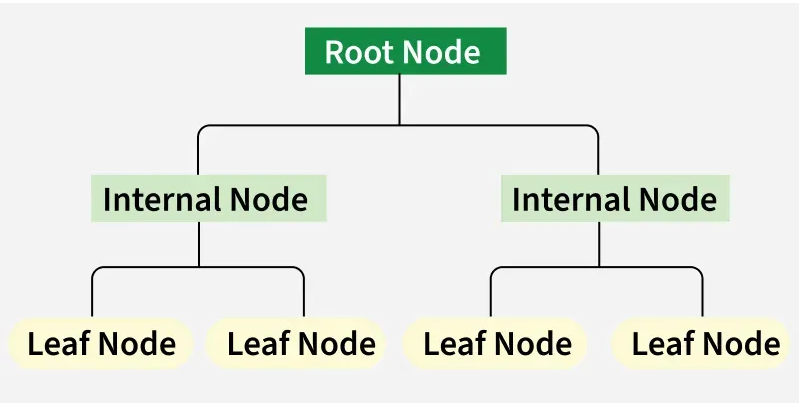<br><br>

A Decision Tree also helps with decision-making by showing possible outcomes clearly. By looking at the 'branches' we can quickly compare options and figure out the best choice.<br><br>

There are mainly two types of Decision Trees based o the target variable:<br><br>

1. Classification Trees -> Used for predicting categorical outcomes like spam or not spam. These trees split the data based on features to classify data into predefined categories.<br><br>

2. Regression Trees -> Used for predicting continous outcomes like predicting house prices. Instead of assigning categories, it provides numberical predictions based on the input features.<br><br>

How do Decision Trees Work?<br><br>

1. Start with the Root Node -> It bagins with a main questions at the root node which is derived from the dataset's features<br><br>

2. Ask Yes/No Questions -> From the root, the tree asks a series of yes/no questions to split the data into subsets based on specific attributes<br><br>

3. Branching Based on Answers -> Each question leads to different braches:<br>
- If the answer is 'YES', the tree follows one path<br>
- If the answer is 'NO', the tree follows another path<br><br>

4. Continue Splitting -> This branching continues through further decisions helps in reducing the data down step-by-step<br><br>

5. Reach the Leaf Node -> The process ends when there are no more useful questions to ask leading to the leaf node where the final decision or prediction is made<br><br>

Let us look at a simple example to see how it works. Imagine we need to decide whether to drink coffee based on the time of the day and how tired we feel. The tree first checks the time:<br><br>

1. In the Morning -> It asks 'Tired?'<br><br>

- If 'YES', the tree suggests drinking coffee<br>
- If 'NO', it says no coffee is needed<br><br>

2. In the afternoon -> It asks again 'Tired?'<br><br>

- If 'YES', it suggest drinking coffee<br>
- If 'NO', no coffee is needed<br><br>

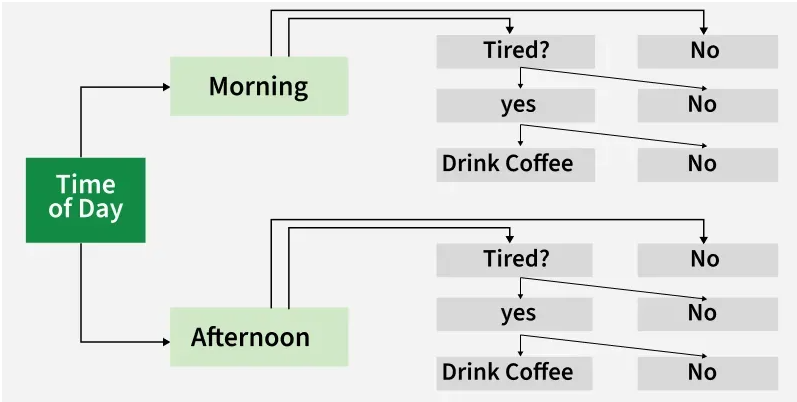<br><br>

Splitting Criteria in Decision Trees<br><br>

In a Decision Tree, the process of splitting data at each node is important. The splitting criteria finds the best feature to split the data on. Common splitting criteria include Gini Impurity and Entropy.<br><br>

- Gini Impurity -> This criterian measures how 'impure' a node is. The lower the Gini impurity the better the feature splits the data into distinct categories<br>
- Entropy -> This measures the amount of uncertanty or disorder in the data. The tree tries to reduce the emtropy by splitting the data on features that provide the most information about the target variable<br><br>

These criteria help decide which features are useful for making the best split at each decision point in the tree<br><br>

Prunning in Decision Trees<br><br>

- Prunning in an importnat technique used to prevent overfitting in Decision Trees. Overfitting occurs when a tree becomes too deep and starts to memorize the training data rather than learning general patterns. This leads to poor performance on new, unseen data<br>
- This technique reduces the complexity of the tree by removing branches that have little predictive power. It improves model performance by helping the tree generalize better to new data. It also makes the model simpler and faster to deploy<br>
- It is useful when a Decision Tree is too deep and starts to capture noise in the data<br><br>

Advantages of Decision Trees<br><br>

- Easy to understand -> Decision Trees are visual which makes it easy to follow the decision-making process<br>
- Versatility -> Can be used for both classification and regression problems<br>
- No Need for Feature Scaling -> Unlike many machine learning models, it does not require us to scale or normalize our data<br>
- Handles Non-Linear Relationships -> It captures complex, non-linear relationships between features and outcomes effectively<br>
- Interpretability -> The tree structure is easy to interpret helping in allowing users to understand the reasoning behind each decision<br>
- Handles Missing Data -> It can handle missing values by using startegies like assigning the most common value or ignoring missing data during splits<br><br>

Disadvantages of Decision Trees<br><br>

- Overfitting -> They can overfit the training data if they are too deep which means they memorize the data instead of learning general patterns. This leads to poor performance on unseen data<br>
- Instability -> It can be unstable which means that small changes in the data may lead to significant differences in the tree structure and predictions<br>
- Bias towards features with Many Categories -> It can become biased toward features with many distinct values which focuses too mucn on them and potentially missing other importnat features which can reduce prediction accuracy<br>
- Difficulty in Capturing Complex Interactions -> Decision Trees may struggke ti campture complex interactions between features which helps in making them less effective for certain types of data<br>
- Computationally Expensive for Large Datasets -> For large datasets, buidling and pruning a Decision Tree can be computationally intensive, especially as the tree depth increases<br><br>

Applications of Decision Trees<br><br>

Decision Trees are used across various fields due to their simplicity, interpretability and versatility. Let us look at some key applications:<br><br>

1. Loan Approval in Banking -> Banks use Decision Trees to assess whether a loan application should be approved. The decision is based on factors like credit score, income, employment status, and loan history. This helps predict approval or rejection - helping in enabling quick and reliable decisions<br><br>

2. Medical Diagnosis -> In healthcare they assist in diagnosting diseases. For example, they can predict whether a patient has diabetes based on clinical data like glucose level, BMI, and blood pressure. This helps classify patients into diabetic or non-diabetic categories, supporting early diagnosis and treatment<br><br>

3. Predicting Exam Results in Education -> Educational institutions use Decision Trees to predict whether a student will pass or fail based on factor like attendance, study time, and past grades. This helps teaches identidy at-risk students and offer target support<br><br>

4. Customer Churn Prediction -> Companies use Decision Trees to predict whether a customer will leave or stau based on behaviour patterns, purchase history, and interactions. This allows businessess to take proactive steps to retain customers<br><br>

5. Fraud Detection -> In finance, Decision Trees are used to detects fraudulent activities, such as credit card fraud. By analyzing past transation data and patterns, Decision Trees can identidy suspicious activities and flag them for further investigation<br><br>

A Decision Tree can also be used to help build automated predictive models, which have applications in machine learning, data mining, and statistics. By mastering Decision Trees, we can gain a deeper understanding of data and make more informed decisions across different fields.<br><br>

https://www.geeksforgeeks.org/machine-learning/decision-tree/<br><br>

What is a decision tree, and how do you create one?<br><br>

Key Takeaways<br><br>

- A decision tree is a visual diagram that maps out various choices and their potential consequences to help teams make smarter, data-driven decisions<br>
- This structure breaks complex problems into a series of simples yes-or-no questions that almost anyone can follow<br>
- Unilizing decision trees in strategis planning provides a common language for cross-functional teams to evaluate uncertain outcomes<br>
- Define your target variable and collect relevant data before building your tree to ensure it addresses the right business problem<br><br>

Making good decisions is tough, especially when you have multiple options and uncertain outcomes.<br><br>

Decision trees give you a clear way to map out choices and their potential consequences, helping you make smarter decisions with confidence.<br><br>

What is a decision tree?<br><br>

A decision tree is a diagram in the shapre of an upside-down tree that shown the different choices and possible outcomes of a decision. It is essentially a guide for decision-making, with each fork in the road representing a choice you need to make.<br><br>

Every decision tree has three main parts:<br><br>

- Nodes -> These are points where decisions are made or outcomes are shown<br>
- Branches -> These connect nodes and represent the available choices our outcomes<br>
- Leaves -> These are the final outcomes at the end of each path<br><br>

This simple structure makes comples decisions easier to understand and communicate. Unlike complicated algorithms or dense spreadsheets, decision trees show your thinking process in a way that almost anyone can follow.<br><br>

What is a Decision Tree used for?<br><br>

Decision trees are not just theoretical tools, they have real-world applications accross many fields, including:<br><br>

- Classification -> Decision trees categorize data into distinct groups. For example, an email service might use a decision tree to sort messages into 'spam' or 'not spam' based on specific chaacteristics<br><br>

- Regression -> Decision trees can predict continous values, like estimating how much a customer might spend based on their browsing history<br><br>

- Business decision analysis -> Companies utilize decision trees to evaluate options when launching new peoducts, entering new markets, or making inverstment decisions<br><br>

You will find decision trees being used for cutomer segmentation (determining which customers are likely to respond to specific offers), medical diagnoses (hepling doctors rule out conditions based on symptoms), and loan approvals (deciding whether an applicatint is likely to repay their loan). Whne cross-functional teams face complex decisions, decision trees provide a common language everyone can understand.<br><br>

How do decision trees work?<br><br>

Decision trees break down comples decisions into a series of simpler choices. The process stats witha single questions at the top node, then branches out based on possible answers.<br><br>

At each node, the tree asks a question about one specific feature of your data. For exaple: 'Is the customer over 30 years old?' or 'Has this person missed a payment in the last year?' -> The answers determine which branch to follow.<br><br>

The math behind this process invlves concepts like:<br><br>

- Splitting -> Divinding data into subsets based on feature values<br>
- Impurity measures -> Calculating how mixed the data is at each node<br>
- Decision paths -> The sequence of decisions that leads to a particular outcome<br><br>

The goal is to create splits that most effectively separate the data into meaningful groups. Good decision trees make the most informative splits early on, separating the data as cleanly as possible with each decision.<br><br>

Types of decision trees<br><br>

https://www.atlassian.com/work-management/project-management/decision-tree<br><br>

In [6]:
# ============================================================
# DECISION TREE
# Easy to interpret. No scaling needed. Can overfit.
# Look for high training accuracy but lower test accuracy (overfitting).
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # no scaling needed

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Decision Tree Accuracy: 0.9518716577540107


Test Accuracy: 0.9519
Train Accuracy: 1.0000
If Train >> Test, the model is overfitting.

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        94
           1       0.92      0.99      0.95        93

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



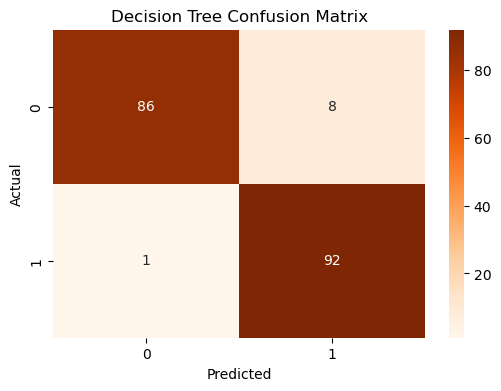

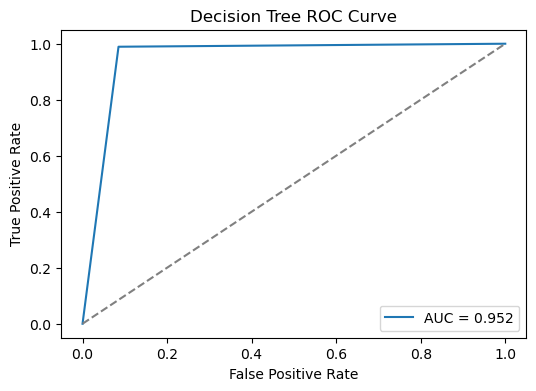

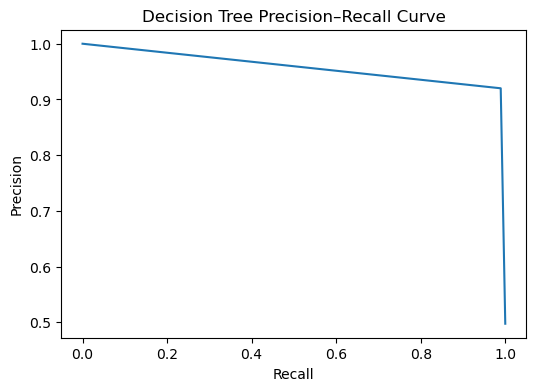


Feature Importance:
                          Feature  Importance
9           Water_Intake (liters)    0.506969
2                      Height (m)    0.201165
8                  Fat_Percentage    0.112306
1                     Weight (kg)    0.103372
6        Session_Duration (hours)    0.038151
7                 Calories_Burned    0.010022
12                            BMI    0.008910
4                         Avg_BPM    0.005646
10  Workout_Frequency (days/week)    0.004302
15                   Workout_Yoga    0.004033
13                   Workout_HIIT    0.003585
3                         Max_BPM    0.000869
0                             Age    0.000670
5                     Resting_BPM    0.000000
11               Experience_Level    0.000000
14               Workout_Strength    0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_14172\2820223216.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')


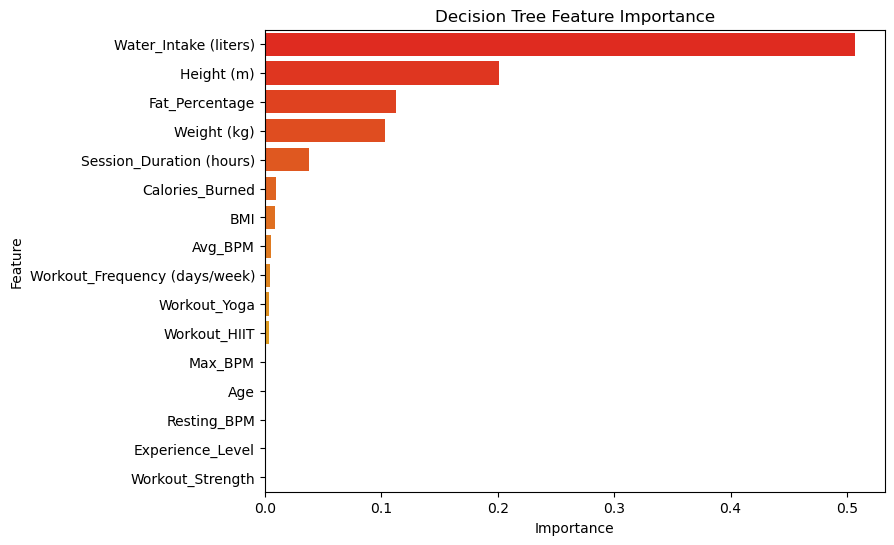

In [16]:
# ============================================================
#   DECISION TREE — FULL MODEL EVALUATION SUITE
#   This cell trains the Decision Tree and evaluates it using:
#     ✔ Accuracy
#     ✔ Classification Report
#     ✔ Confusion Matrix
#     ✔ ROC Curve + AUC
#     ✔ Precision–Recall Curve
#     ✔ Feature Importance (unique to trees)
#     ✔ Overfitting check (train vs test accuracy)
#   Every section includes comments explaining what to look for.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import pandas as pd

# ------------------------------------------------------------
# 1. Train the Decision Tree model
# ------------------------------------------------------------
# Trees do NOT require scaling.
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]  # needed for ROC/PR curves


# ------------------------------------------------------------
# 2. Accuracy Score (Test Set)
# ------------------------------------------------------------
# Accuracy = proportion of correct predictions.
# Trees often overfit, so accuracy alone is not enough.
test_accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Test Accuracy: {test_accuracy:.4f}")


# ------------------------------------------------------------
# 3. Overfitting Check — Train Accuracy vs Test Accuracy
# ------------------------------------------------------------
# If train accuracy is much higher than test accuracy,
# the tree is memorising the training data (overfitting).
train_accuracy = accuracy_score(y_train, tree.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.4f}")
print("If Train >> Test, the model is overfitting.\n")


# ------------------------------------------------------------
# 4. Classification Report
# ------------------------------------------------------------
# Shows precision, recall, and F1-score for each class.
# Look for balanced values across both classes.
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------
# Shows EXACTLY where the model is making mistakes.
# Diagonal = correct predictions.
# Off-diagonal = errors.
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------------
# 6. ROC Curve + AUC Score
# ------------------------------------------------------------
# ROC curve shows how well the model separates the two classes.
# AUC close to 1.0 = excellent.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7. Precision–Recall Curve
# ------------------------------------------------------------
# Useful when one class is less common.
# Look for curves that stay high (good precision)
# and far right (good recall).
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_tree)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Decision Tree Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ------------------------------------------------------------
# 8. Feature Importance (unique to Decision Trees)
# ------------------------------------------------------------
# Shows which features the tree used most for splitting.
# Higher importance = more influence on predictions.
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')
plt.title("Decision Tree Feature Importance")
plt.show()
